# Demo 2: Spatial Distribution of Training Data

Visualize the geographic distribution of the `streetview_pano` fine-tuning dataset.
Hot areas (red/yellow) indicate dense street-view coverage; cold areas (blue/transparent)
indicate sparse regions. This contextualizes the model's performance biases.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

_root = Path.cwd().parent if Path.cwd().name == 'demos' else Path.cwd()
sys.path.insert(0, str(_root))

from demos.demo_utils import load_dataset_coordinates

%matplotlib inline

In [2]:
# Load dataset coordinates
coords = load_dataset_coordinates()
print(f'Loaded {len(coords):,} (lat, lon) pairs from streetview_pano dataset')

Loaded 11,054 (lat, lon) pairs from streetview_pano dataset


In [3]:
# --- 2D KDE on the sphere (wrapping longitude) ---
lats = coords[:, 0]
lons = coords[:, 1]

# Create evaluation grid
n_grid = 300
lat_grid = np.linspace(-90, 90, n_grid)
lon_grid = np.linspace(-180, 180, n_grid)
LON, LAT = np.meshgrid(lon_grid, lat_grid)

# For KDE, we need to handle longitude wrapping.
# We duplicate the data shifted by +/-360 degrees to avoid boundary artifacts.
lons_wrapped = np.concatenate([lons - 360, lons, lons + 360])
lats_wrapped = np.concatenate([lats, lats, lats])

print('Running KDE (this may take a minute for large datasets)...')
kde = gaussian_kde(
    np.vstack([lats_wrapped, lons_wrapped]),
    bw_method='scott'
)

# Evaluate on the grid
grid_points = np.vstack([LAT.ravel(), LON.ravel()])
density = kde(grid_points).reshape(LAT.shape)
print('KDE complete.')

Running KDE (this may take a minute for large datasets)...
KDE complete.


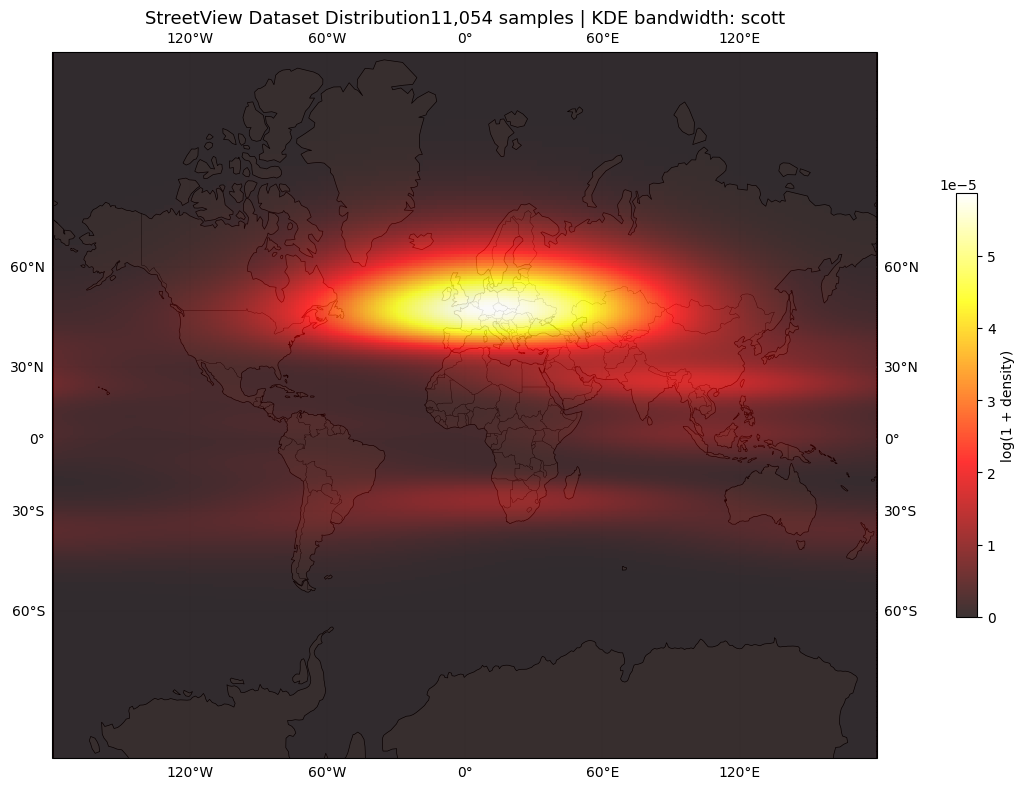

In [4]:
# --- Plot density heatmap ---
# Use log scale for better visual contrast
density_log = np.log1p(density)

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    _has_cartopy = True
except ImportError:
    _has_cartopy = False

if _has_cartopy:
    fig, ax = plt.subplots(figsize=(16, 8), subplot_kw={'projection': ccrs.Mercator()})
    ax.set_global()
    ax.add_feature(cfeature.LAND, facecolor='#e8e8e8', zorder=0)
    ax.add_feature(cfeature.OCEAN, facecolor='#c8d8e8', zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=1)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, zorder=1)
    ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

    im = ax.pcolormesh(
        lon_grid, lat_grid, density_log,
        cmap='hot', alpha=0.8,
        transform=ccrs.PlateCarree(), zorder=2,
    )
else:
    fig, ax = plt.subplots(figsize=(16, 8))
    ax.set_xlim(-180, 180)
    ax.set_ylim(-90, 90)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.grid(True, alpha=0.3)
    im = ax.pcolormesh(lon_grid, lat_grid, density_log, cmap='hot', alpha=0.8)

plt.colorbar(im, ax=ax, shrink=0.6, label='log(1 + density)')
title_line1 = f'StreetView Dataset Distribution'
title_line2 = f'{len(coords):,} samples | KDE bandwidth: scott'
ax.set_title(title_line1 + '' + title_line2, fontsize=13)
fig.tight_layout()
plt.show()

In [5]:
# --- Top regions by sample count ---
# Bin by country/region using simple lat/lon bounds
regions = {
    'United States': (25, 49, -125, -66),
    'Europe': (36, 70, -10, 40),
    'Japan': (30, 46, 128, 146),
    'Southeast Asia': (-10, 25, 95, 140),
    'South America': (-55, 12, -80, -34),
    'Australia': (-40, -10, 112, 155),
    'Africa': (-35, 37, -20, 52),
}

print()
print('Samples per region:')
for name, (lat_lo, lat_hi, lon_lo, lon_hi) in regions.items():
    mask = (lats >= lat_lo) & (lats <= lat_hi) & (lons >= lon_lo) & (lons <= lon_hi)
    count = mask.sum()
    pct = 100 * count / len(coords)
    print(f'  {name:<18s}: {count:>6,}  ({pct:5.1f}%)')
other = len(coords) - sum(
    ((lats >= r[0]) & (lats <= r[1]) & (lons >= r[2]) & (lons <= r[3])).sum()
    for r in regions.values()
)
print(f'  {"Other":<18s}: {other:>6,}')


Samples per region:
  United States     :    287  (  2.6%)
  Europe            :  5,667  ( 51.3%)
  Japan             :    229  (  2.1%)
  Southeast Asia    :  1,292  ( 11.7%)
  South America     :    945  (  8.5%)
  Australia         :    200  (  1.8%)
  Africa            :    894  (  8.1%)
  Other             :  1,540
